## Composite veg health code

- Suggestion: Group 10 day time chunks into bins of pre-onset (-60>-30 days), onset (-30>0 days), early wet season (0>30 days), wet season (30 days> end of season). Could then pick timesteps within those bins where a threshold % of grids had FAPAR below a threshold to create a set of extreme composite that could be significance tested. Could look at concurrent precipitation or precipitation lagged by one timestep or 10 days.

- WHY: The previous tests are concerned with seasonality and causality but this test shows impact on intra-seasonal variability more clearly



In [1]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import pandas as pd
import gc
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings('ignore')

In [2]:
datap = "/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/"
datac = "/Users/ellendyer/Documents/GitHub/F4R_data/"
dataf = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_fapar/"
datal = "/Users/ellendyer/Documents/GitHub/F4R_data/analysed_lai/"

In [3]:
fapar = xr.open_mfdataset(dataf+'fapar_*_reg_regrid.nc')
precip = xr.open_mfdataset(datac+'chirps_10day_reg_regrid.nc') 
lai = xr.open_mfdataset(datal+'lai_*_reg_regrid.nc') 
sif = xr.open_mfdataset(datac+'sif_10day_reg_regrid.nc') 
hdo = xr.open_mfdataset(datac+'hdo_10day_reg_regrid.nc') 
#tropess = xr.open_mfdataset('/Users/ellendyer/Documents/GitHub/F4R_data/tropess_gridded_caf_lowmid.nc') 
#tropess = tropess.interp(lat=np.arange(tropess.coords["lat"].min().values,tropess.coords["lat"].max().values,0.25), lon=np.arange(tropess.coords["lon"].min().values,tropess.coords["lon"].max().values,0.25), method="linear")
    

In [4]:
#Flatten the array to get time and all space points as a 1d dimension
flat_fapar = fapar.stack(space=('lat','lon')).compute()

#Drop all points where fAPAR isn't above a certain threshold and count remaining points
#above this threshold > get a count per timestep
#thresh = fAPAR value of 0.5
pass_fapar_thresh = flat_fapar.where(flat_fapar>0.5,drop=True).count(dim='space')

#Keep timesteps where less than a % of the total possible space points are above the 
#fAPAR threshold
#thresh = 60% of points
pass_extent_thresh = pass_fapar_thresh.where(pass_fapar_thresh<0.6*flat_fapar.sizes['space'],drop=True)

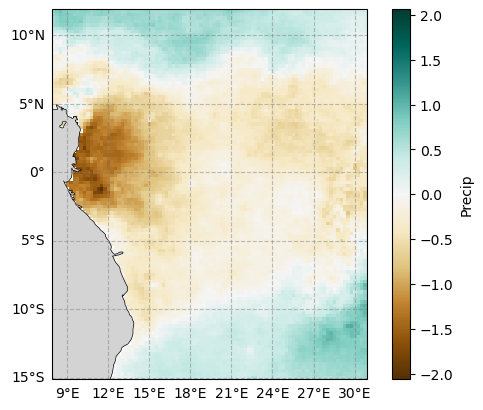

<Figure size 640x480 with 0 Axes>

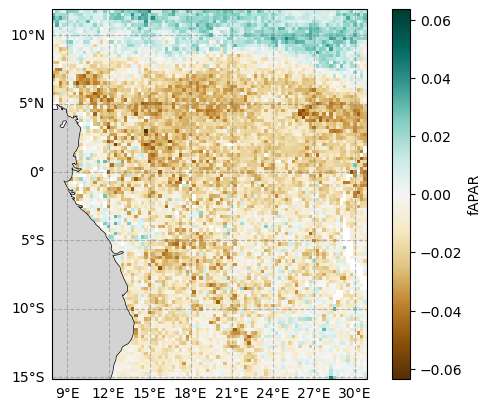

<Figure size 640x480 with 0 Axes>

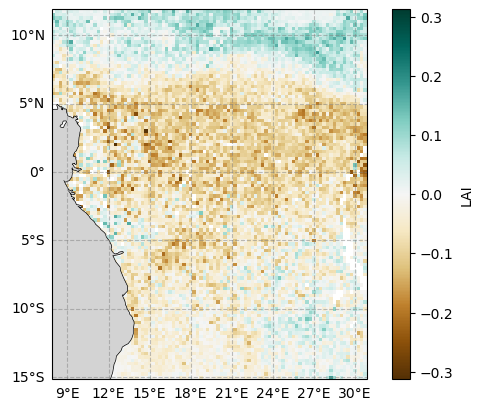

<Figure size 640x480 with 0 Axes>

In [22]:
#Select points in other variables which have the same timesteps as pass_extent_thresh
precip_comp = precip.sel(time=pass_extent_thresh.time.values,drop=True)
lai_comp = lai.sel(time=pass_extent_thresh.time.values,drop=True) 
fapar_comp = fapar.sel(time=pass_extent_thresh.time.values,drop=True) 
#hdo_comp = hdo.sel(time=pass_extent_thresh.time.values,drop=True) 

#Plot the difference between selected composite and overall mean
precip_diff = precip_comp.mean('time')-precip.mean('time')
fapar_diff = fapar_comp.mean('time')-fapar.mean('time')
lai_diff = lai_comp.mean('time')-lai.mean('time')
#hdo_diff = hdo_comp.mean('time')-hdo.mean('time')

cmap=plt.cm.BrBG
fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
precip_diff['precip'].plot.pcolormesh(
                        #vmin=0.25, vmax=0.8,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": "Precip"},
                        transform = ccrs.PlateCarree())
axs.coastlines()
axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
plt.show()
plt.clf()

cmap=plt.cm.BrBG
fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
fapar_diff['fAPAR'].plot.pcolormesh(
                        #vmin=0.25, vmax=0.8,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": "fAPAR"},
                        transform = ccrs.PlateCarree())
axs.coastlines()
axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
plt.show()
plt.clf()

cmap=plt.cm.BrBG
fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
lai_diff['LAI'].plot.pcolormesh(
                        #vmin=0.25, vmax=0.8,
                        cmap=cmap,
                        rasterized=True,
                        add_colorbar=True,
                        cbar_kwargs={"label": "LAI"},
                        transform = ccrs.PlateCarree())
axs.coastlines()
axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
gl = axs.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
plt.show()
plt.clf()

#cmap=plt.cm.BrBG
#fig, axs = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
#hdo_diff['deltaD'].plot.pcolormesh(
#                        #vmin=0.25, vmax=0.8,
#                        cmap=cmap,
#                        rasterized=True,
#                        add_colorbar=True,
#                        cbar_kwargs={"label": "deltaD"},
#                        transform = ccrs.PlateCarree())
#axs.coastlines()
#axs.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
#gl = axs.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
#gl.top_labels = False
#gl.right_labels = False
#plt.show()
#plt.clf()
#